# v2 — GraphSAGE on hard-negative-aware data

## What changed vs `03_graphsage.ipynb` (v1)

Same model architecture (2-layer SAGE encoder + MLP decoder + BPR loss). Only the data interface and eval reporting change:

1. **Data dir**: `data/processed/` → `data/processed_v2/`. v2 prep saves `negatives_random` + `negatives_hard` (training) and `negative_locals_mixed` (eval) per supervision example.
2. **`NEG_STRATEGY` flag** — `'random' | 'hard' | 'mixed'`. At each batch we pick training negatives from the pre-computed lists according to this flag. Default `'mixed'` (50/50 hard+random, matches eval distribution).
3. **Eval reads `negative_locals_mixed`** — the 1K candidate set is now ~50% hard / ~50% random per author, identical regime as the upcoming v2 GAT for fair head-to-head.
4. **Full-pool test eval** (T1) — a new `evaluate_full_pool()` function ranks against **all ~546K papers** at test time using the saved `known_locals` to mask. This is the headline number to report. The 1K-mixed eval is kept as a faster reference.

Author representation is unchanged: mean-pool of paper embeddings over the author's pre-year history. No learned author embedding table at any point — keeps the model fully inductive (any new user with a list of read papers can be embedded immediately).

## Imports

PyTorch + PyG for the GNN; numpy/random for reproducibility; pathlib for filesystem paths. We import `SAGEConv` (the GraphSAGE convolution that aggregates neighbors with a learnable transform).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from pathlib import Path

from torch_geometric.nn import SAGEConv

## Reproducibility and device

Pin random seeds so a re-run reproduces the exact training trajectory (same shuffle order, same negative samples drawn from each example's pre-computed lists). Pick GPU automatically if available.

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Configuration

All knobs in one place. The NEW v2 flag is **`NEG_STRATEGY`** — controls which pre-computed negatives are used during training:
- `'random'` — only `ex['negatives_random']` (matches v1's behavior; baseline regime).
- `'hard'` — only `ex['negatives_hard']` (stress test).
- `'mixed'` — half random, half hard (default; aligns with eval candidate composition).

Eval composition is fixed by the prep notebook (50/50 hard/random in the 1K candidate pool). Architecture / optimizer / schedule unchanged from v1 so any difference in the reported number is attributable to data, not to the model.

In [3]:
PROCESSED_DIR = Path("./data/processed_v2")  # v2 prep output

# --- Architecture ---
INPUT_DIM = 768
HIDDEN_DIM = 256
OUTPUT_DIM = 256
DROPOUT = 0.2

# --- Optimization ---
LR = 1e-3
WEIGHT_DECAY = 1e-5
NUM_EPOCHS = 60
BATCH_SIZE = 512
EVAL_EVERY = 5

# --- Negative strategy (NEW in v2) ---
NEG_STRATEGY = 'mixed'   # 'random' | 'hard' | 'mixed'

print(f"Data dir:       {PROCESSED_DIR}")
print(f"NEG_STRATEGY:   {NEG_STRATEGY}")
print(f"Architecture:   SAGE({INPUT_DIM}->{HIDDEN_DIM}->{OUTPUT_DIM}), dropout={DROPOUT}")
print(f"Optim:          Adam(lr={LR}, wd={WEIGHT_DECAY}), epochs={NUM_EPOCHS}, batch={BATCH_SIZE}")

Data dir:       data/processed_v2
NEG_STRATEGY:   mixed
Architecture:   SAGE(768->256->256), dropout=0.2
Optim:          Adam(lr=0.001, wd=1e-05), epochs=60, batch=512


## Step 1 — Load data

We load three things up front:
- `train_years.pt` — list of supervision years (2005..2016 for v2 prep defaults).
- `metadata.pt` — dataset constants and the FoS level / hard-frac actually used.
- `val.pt` — kept in memory the whole run for fast per-epoch validation.

Per-year training files are loaded lazily inside the loop to avoid holding all years' graphs simultaneously.

In [4]:
train_years = torch.load(PROCESSED_DIR / "train_years.pt", weights_only=False)
metadata = torch.load(PROCESSED_DIR / "metadata.pt", weights_only=False)
val_data = torch.load(PROCESSED_DIR / "val.pt", weights_only=False)

print(f"Training years: {train_years}")
print(f"Embed dim:      {metadata['embed_dim']}")
print(f"FoS level:      {metadata['fos_level']}")
print(f"Eval pool:      {metadata['eval_total_candidates']} candidates, hard frac {metadata['eval_hard_frac']}")
print(f"Val graph:      {val_data['homo_graph'].num_nodes:,} papers, "
      f"{val_data['homo_graph'].edge_index.shape[1]:,} edges")
print(f"Val examples:   {len(val_data['supervision']):,}")

Training years: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]
Embed dim:      768
FoS level:      2
Eval pool:      1000 candidates, hard frac 0.5
Val graph:      456,776 papers, 8,993,796 edges
Val examples:   43,562


## Sanity peek at one training year

Confirms the v2 data shape: each training example carries **both** `negatives_random` and `negatives_hard`, plus `positive_locals` and `history_locals`. If this peek shows `negative_locals` (singular) instead, you're pointed at v1 data — re-check `PROCESSED_DIR`.

In [5]:
sample_data = torch.load(PROCESSED_DIR / f"train_year_{train_years[0]}.pt", weights_only=False)
print(f"Sample year {train_years[0]}:")
print(f"  Top-level keys: {list(sample_data.keys())}")
print(f"  Graph: {sample_data['homo_graph'].num_nodes:,} papers, "
      f"{sample_data['homo_graph'].edge_index.shape[1]:,} edges")
print(f"  Supervision examples: {len(sample_data['supervision']):,}")
if sample_data['supervision']:
    ex = sample_data['supervision'][0]
    print(f"  Example keys: {list(ex.keys())}")
    print(f"  Example sizes: {len(ex['positive_locals'])} pos, "
          f"{len(ex['negatives_random'])} rand-neg, "
          f"{len(ex['negatives_hard'])} hard-neg, "
          f"{len(ex['history_locals'])} history")
    assert 'negatives_random' in ex and 'negatives_hard' in ex, \
        "Expected v2 schema (negatives_random/_hard). Are you pointed at processed_v2?"

Sample year 2005:
  Top-level keys: ['supervision_year', 'homo_graph', 'homo_g2l', 'homo_l2g', 'hetero_graph', 'hetero_paper_g2l', 'hetero_paper_l2g', 'author_histories', 'supervision', 'fos_level']
  Graph: 107,163 papers, 1,288,986 edges
  Supervision examples: 14,780
  Example keys: ['author_id', 'positive_locals', 'negatives_random', 'negatives_hard', 'history_locals']
  Example sizes: 3 pos, 15 rand-neg, 15 hard-neg, 13 history


## Step 2 — GraphSAGE encoder

Two SAGEConv layers with ReLU + dropout between. Each `SAGEConv` aggregates neighbor features (mean by default), concatenates with the node's own features, and applies a learned linear transform. After 2 layers, every paper's embedding sees its 2-hop citation neighborhood.

In [6]:
class GraphSAGEEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.2):
        super().__init__()
        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, output_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = self.conv2(h, edge_index)
        return h

### Sanity test — encoder shape and validity

Verifies the encoder produces `(num_nodes, OUTPUT_DIM)` embeddings, no NaN/Inf, and that different papers get different vectors (trivial check that the model isn't outputting a constant).

In [7]:
test_encoder = GraphSAGEEncoder(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM, DROPOUT)
test_graph = sample_data['homo_graph']
test_encoder.eval()
with torch.no_grad():
    test_out = test_encoder(test_graph.x, test_graph.edge_index)
print(f"In: {test_graph.x.shape}  Out: {test_out.shape}")
assert test_out.shape == (test_graph.num_nodes, OUTPUT_DIM)
assert not torch.isnan(test_out).any() and not torch.isinf(test_out).any()
if test_graph.num_nodes > 1:
    assert not torch.allclose(test_out[0], test_out[1])
print(f"Encoder params: {sum(p.numel() for p in test_encoder.parameters()):,}")
print("[PASS] encoder")
del test_encoder, test_out

In: torch.Size([107163, 768])  Out: torch.Size([107163, 256])
Encoder params: 524,800
[PASS] encoder


## Step 3 — MLP decoder

Concatenates author and paper embeddings (256-dim total), passes through `Linear(256→128) → ReLU → Linear(128→1)` to produce a scalar score. Higher score = model believes the (author, paper) pair is a positive.

In [8]:
class MLPDecoder(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.fc1 = nn.Linear(2 * emb_dim, emb_dim)
        self.fc2 = nn.Linear(emb_dim, 1)

    def forward(self, author_emb, paper_emb):
        combined = torch.cat([author_emb, paper_emb], dim=-1)
        h = F.relu(self.fc1(combined))
        return self.fc2(h).squeeze(-1)

### Sanity test — decoder shapes

Feed random author/paper embeddings, confirm scalar output per pair, no NaN, and non-degenerate variance.

In [9]:
test_decoder = MLPDecoder(OUTPUT_DIM)
B = 16
fa = torch.randn(B, OUTPUT_DIM); fp = torch.randn(B, OUTPUT_DIM)
with torch.no_grad():
    s = test_decoder(fa, fp)
assert s.shape == (B,) and not torch.isnan(s).any() and s.std() > 0
print(f"Decoder params: {sum(p.numel() for p in test_decoder.parameters()):,}")
print("[PASS] decoder")
del test_decoder, fa, fp, s

Decoder params: 131,585
[PASS] decoder


## Step 4 — Author representation (mean-pool)

An author has no node in the homogeneous graph. Their representation is the **mean** of their pre-year papers' GNN embeddings — fully inductive (any new author with a list of read papers gets an embedding immediately).

We accept a list of supervision examples and return one author embedding per example, in the same order, so downstream batching is straightforward.

In [10]:
def compute_author_embeddings(paper_embeddings, supervision_examples):
    embs = []
    for ex in supervision_examples:
        hids = torch.tensor(ex['history_locals'], dtype=torch.long)
        embs.append(paper_embeddings[hids].mean(dim=0))
    return torch.stack(embs)

### Sanity test — mean-pool correctness

Construct toy paper embeddings, hand-compute the expected mean for one author, confirm exact match.

In [11]:
fpe = torch.randn(100, OUTPUT_DIM)
fex = [
    {'history_locals': [0, 1, 2]},
    {'history_locals': [5]},
    {'history_locals': [3, 7, 9, 12]},
]
ae = compute_author_embeddings(fpe, fex)
assert ae.shape == (3, OUTPUT_DIM)
assert torch.allclose(ae[0], fpe[[0, 1, 2]].mean(dim=0))
assert torch.allclose(ae[1], fpe[5])
print("[PASS] mean-pool")
del fpe, fex, ae

[PASS] mean-pool


## Step 5 — BPR loss

Bayesian Personalized Ranking optimizes ranking directly: for each (positive, negative) pair, push positive's score above negative's via `-log sigmoid(pos - neg)`. We pair each positive with each negative in the example via broadcasting and average.

Why BPR rather than binary cross-entropy: BPR is invariant to the absolute score scale, only relative ordering matters — perfect for retrieval.

In [12]:
def bpr_loss(pos_scores, neg_scores):
    diff = pos_scores.unsqueeze(1) - neg_scores.unsqueeze(0)
    return -F.logsigmoid(diff).mean()

### Sanity test — BPR ordering

Three regimes: `pos >> neg` should give near-zero loss; `pos << neg` large loss; equal scores `log(2) ≈ 0.693`.

In [13]:
lg = bpr_loss(torch.tensor([5., 6., 7.]), torch.tensor([-5., -6., -7.])).item()
lb = bpr_loss(torch.tensor([-5., -6., -7.]), torch.tensor([5., 6., 7.])).item()
le = bpr_loss(torch.tensor([0., 0.]), torch.tensor([0., 0.])).item()
print(f"good={lg:.4f}  bad={lb:.4f}  equal={le:.4f}")
assert lg < le < lb and abs(le - 0.6931) < 0.01
print("[PASS] BPR loss")

good=0.0000  bad=12.0000  equal=0.6931
[PASS] BPR loss


## Step 6 — Negative-sampling helper (NEW in v2)

Each training example carries `negatives_random` and `negatives_hard` (pre-computed, length `NEG_SAMPLES * |positives|` each). At training time we pick from them according to `NEG_STRATEGY`:

- `random` → first N from `negatives_random`.
- `hard` → first N from `negatives_hard`.
- `mixed` → half from random, half from hard.

`N` is the per-example total negatives, which equals `len(negatives_random)` in practice (prep already chose `NEG_SAMPLES * |positives|`). We slice to be defensive in case future prep runs save more than needed.

This lets the same training notebook produce three ablation runs by toggling one flag — no re-prep required.

In [14]:
def get_train_negatives(ex, strategy):
    """Return a list of training negatives for one example, per NEG_STRATEGY.

    Robust to size mismatches: if a strategy needs more than the example provides
    (e.g. tiny hard pool topped up with random at prep time), it returns whatever
    the example actually has.
    """
    if strategy == 'random':
        return list(ex['negatives_random'])
    if strategy == 'hard':
        return list(ex['negatives_hard'])
    # mixed: half from each, lengths match by construction
    n = len(ex['negatives_random'])
    half = n // 2
    return list(ex['negatives_random'][:half]) + list(ex['negatives_hard'][:n - half])

## Step 7 — Train one year (GPU-efficient)

Strategy on 500K-paper graphs:
1. **Encode all papers once with `.detach()`** — one forward through the GNN, then detach so subsequent backward()'s only flow through the MLP. Saves ~10× GPU memory.
2. **Vectorize per-batch scoring** — collect all (author, pos+neg paper) pairs into flat tensors, one decoder forward for the entire batch.
3. **One GNN gradient step at the end** — small random sample re-encoded **with** gradients, single backward through the encoder, so the GNN actually learns. Same trick as v1.

The only line that changes from v1 is where `ex['negative_locals']` was — now we call `get_train_negatives(ex, NEG_STRATEGY)`.

In [15]:
def train_one_year(encoder, decoder, optimizer, year_data, device,
                   batch_size=512, neg_strategy='mixed'):
    encoder.train(); decoder.train()
    graph = year_data['homo_graph'].to(device)
    examples = year_data['supervision']
    if not examples:
        return 0.0

    # 1. Encode once, detach for cheap MLP-only batches
    paper_embs = encoder(graph.x, graph.edge_index).detach()

    indices = list(range(len(examples)))
    random.shuffle(indices)
    total_loss, num_batches = 0.0, 0

    for batch_start in range(0, len(indices), batch_size):
        bidx = indices[batch_start:batch_start + batch_size]
        bex = [examples[i] for i in bidx]
        author_embs = compute_author_embeddings(paper_embs, bex)

        all_a, all_p, bounds = [], [], []
        offset = 0
        for i, ex in enumerate(bex):
            negs = get_train_negatives(ex, neg_strategy)
            if not negs:
                continue
            n_pos, n_neg = len(ex['positive_locals']), len(negs)
            a = author_embs[i]
            pos_ids = torch.tensor(ex['positive_locals'], dtype=torch.long)
            neg_ids = torch.tensor(negs, dtype=torch.long)
            all_a.append(a.unsqueeze(0).expand(n_pos + n_neg, -1))
            all_p.append(torch.cat([paper_embs[pos_ids], paper_embs[neg_ids]], dim=0))
            bounds.append((offset, n_pos, n_neg))
            offset += n_pos + n_neg
        if not all_a:
            continue

        flat_a = torch.cat(all_a, dim=0).to(device)
        flat_p = torch.cat(all_p, dim=0).to(device)
        scores = decoder(flat_a, flat_p)

        batch_loss = torch.tensor(0.0, device=device)
        for start, n_pos, n_neg in bounds:
            ps = scores[start:start + n_pos]
            ns = scores[start + n_pos:start + n_pos + n_neg]
            batch_loss = batch_loss + bpr_loss(ps, ns)
        batch_loss = batch_loss / len(bounds)

        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()
        total_loss += batch_loss.item()
        num_batches += 1

    # 2. Single GNN-grad pass on a small sample so the encoder also learns
    encoder.train()
    sample = random.sample(examples, min(32, len(examples)))
    pe_grad = encoder(graph.x, graph.edge_index)
    ae = compute_author_embeddings(pe_grad, sample)
    gnn_loss = torch.tensor(0.0, device=device)
    for i, ex in enumerate(sample):
        negs = get_train_negatives(ex, neg_strategy)
        if not negs:
            continue
        a = ae[i]
        pos_ids = torch.tensor(ex['positive_locals'], dtype=torch.long, device=device)
        neg_ids = torch.tensor(negs, dtype=torch.long, device=device)
        ps = decoder(a.unsqueeze(0).expand(len(pos_ids), -1), pe_grad[pos_ids])
        ns = decoder(a.unsqueeze(0).expand(len(neg_ids), -1), pe_grad[neg_ids])
        gnn_loss = gnn_loss + bpr_loss(ps, ns)
    gnn_loss = gnn_loss / max(len(sample), 1)
    optimizer.zero_grad(); gnn_loss.backward(); optimizer.step()

    del paper_embs, pe_grad, graph
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return total_loss / max(num_batches, 1)

### Sanity test — one training step actually changes the loss

Train two consecutive steps on the sample year, confirm loss changes (model is updating).

In [16]:
te = GraphSAGEEncoder(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM, DROPOUT).to(device)
td = MLPDecoder(OUTPUT_DIM).to(device)
to = torch.optim.Adam(list(te.parameters()) + list(td.parameters()), lr=LR, weight_decay=WEIGHT_DECAY)
l1 = train_one_year(te, td, to, sample_data, device, batch_size=32, neg_strategy=NEG_STRATEGY)
l2 = train_one_year(te, td, to, sample_data, device, batch_size=32, neg_strategy=NEG_STRATEGY)
print(f"Loss step1={l1:.4f}  step2={l2:.4f}  changed={abs(l1-l2)>1e-6}")
assert l1 > 0 and not np.isnan(l1) and not np.isinf(l1)
print("[PASS] training step")
del te, td, to

Loss step1=0.6904  step2=0.6879  changed=True
[PASS] training step


## Step 8 — Eval on the 1K mixed candidate pool

Per-author: encode the pre-year graph, mean-pool the author's history → author emb, score the ~1000 mixed (positives + negative_locals_mixed) candidates, rank, compute Hits@10 and MRR. Best-rank semantics: if multiple positives, use the highest-ranked one (most lenient — matches v1).

**Only data change vs v1**: read `ex['negative_locals_mixed']` instead of `ex['negative_locals']`. The candidate set is the same size but composition is now ~50% hard / ~50% random.

In [17]:
@torch.no_grad()
def evaluate(encoder, decoder, eval_data, device, eval_batch_size=64):
    encoder.eval(); decoder.eval()
    graph = eval_data['homo_graph'].to(device)
    examples = eval_data['supervision']
    if not examples:
        return {'hits@10': 0.0, 'mrr': 0.0, 'num_authors': 0}

    paper_embs = encoder(graph.x, graph.edge_index).cpu()  # free GPU for scoring
    del graph
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    decoder_cpu = decoder.cpu()

    hits10, mrrs = [], []
    for batch_start in range(0, len(examples), eval_batch_size):
        for ex in examples[batch_start:batch_start + eval_batch_size]:
            hids = torch.tensor(ex['history_locals'], dtype=torch.long)
            a = paper_embs[hids].mean(dim=0)
            pos = ex['positive_locals']
            neg = ex['negative_locals_mixed']
            cand = pos + neg
            cids = torch.tensor(cand, dtype=torch.long)
            cembs = paper_embs[cids]
            scores = decoder_cpu(a.unsqueeze(0).expand(len(cand), -1), cembs)
            _, ranked = scores.sort(descending=True)
            n_pos = len(pos)
            best = float('inf')
            for rk, idx in enumerate(ranked.tolist()):
                if idx < n_pos:
                    best = rk + 1; break
            hits10.append(1.0 if best <= 10 else 0.0)
            mrrs.append(1.0 / best if best != float('inf') else 0.0)
    decoder.to(device)
    return {'hits@10': float(np.mean(hits10)), 'mrr': float(np.mean(mrrs)), 'num_authors': len(examples)}

### Sanity test — eval returns valid metrics

Run on the val data with random init weights. Random baseline is `~10/1000 = 1%`; an untrained model should land in that ballpark.

In [18]:
te = GraphSAGEEncoder(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM, DROPOUT).to(device)
td = MLPDecoder(OUTPUT_DIM).to(device)
r = evaluate(te, td, val_data, device)
print(f"random-init Hits@10={r['hits@10']:.4f}  MRR={r['mrr']:.4f}  authors={r['num_authors']}")
assert 0.0 <= r['hits@10'] <= 1.0 and 0.0 <= r['mrr'] <= 1.0
print("[PASS] eval")
del te, td

random-init Hits@10=0.0491  MRR=0.0275  authors=43562
[PASS] eval


## Step 9 — Full-pool eval (NEW in v2, T1 headline number)

For test we want the realistic recommender number: rank against **all ~546K papers in the pre-test graph**, not just 1K candidates. Prep saved `known_locals` per author (own papers + previously-cited papers) — we mask those out so the model has to surface **new** knowledge, not retrieve already-known papers.

Procedure per author:
1. Mean-pool history → author emb on GPU.
2. Score every paper: `decoder(author_exp, all_paper_embs)` → (N,) scores.
3. Mask `known \ positives` to `-inf` (we still want positives ranked among everything else).
4. Sort, find rank of best positive, log Hits@10 + MRR.

Cost: per-author MLP forward on N papers ≈ 25M FLOPs. For ~30K authors × 546K papers, total ≈ 0.7 PFLOPs — runs in seconds on a modern GPU. Memory peak ≈ `paper_embs` + 1 author's score tensor.

In [19]:
@torch.no_grad()
def evaluate_full_pool(encoder, decoder, eval_data, device):
    encoder.eval(); decoder.eval()
    examples = eval_data['supervision']
    if not examples:
        return {'hits@10': 0.0, 'mrr': 0.0, 'num_authors': 0}
    if 'known_locals' not in examples[0]:
        raise KeyError("Full-pool eval requires 'known_locals' in supervision examples. "
                       "Re-run prep with BUILD_FULL_POOL_TEST=True.")

    graph = eval_data['homo_graph'].to(device)
    paper_embs = encoder(graph.x, graph.edge_index)  # (N, D) on GPU
    N = paper_embs.shape[0]
    del graph
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    hits10, mrrs = [], []
    for ex in examples:
        hids = torch.tensor(ex['history_locals'], dtype=torch.long, device=device)
        a = paper_embs[hids].mean(dim=0)
        pos = set(ex['positive_locals'])
        known_only = set(ex['known_locals']) - pos  # don't mask positives

        # Score every paper
        scores = decoder(a.unsqueeze(0).expand(N, -1), paper_embs)  # (N,)
        if known_only:
            mask = torch.tensor(list(known_only), dtype=torch.long, device=device)
            scores[mask] = float('-inf')

        # Find rank of the best positive
        pos_tensor = torch.tensor(list(pos), dtype=torch.long, device=device)
        _, ranked = scores.sort(descending=True)
        in_pos = torch.isin(ranked, pos_tensor)
        nz = in_pos.nonzero()
        best = (nz[0].item() + 1) if nz.numel() > 0 else float('inf')
        hits10.append(1.0 if best <= 10 else 0.0)
        mrrs.append(1.0 / best if best != float('inf') else 0.0)
    return {'hits@10': float(np.mean(hits10)), 'mrr': float(np.mean(mrrs)), 'num_authors': len(examples)}

## Step 10 — Initialize model + optimizer

Single `Adam` covers both encoder and decoder, with weight decay. `total_params` print confirms architecture matches v1 (encoder ~459K + decoder ~33K = ~492K params). No author embedding table — model stays small and fully inductive.

In [20]:
encoder = GraphSAGEEncoder(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM, DROPOUT).to(device)
decoder = MLPDecoder(OUTPUT_DIM).to(device)
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY,
)
total_params = sum(p.numel() for p in encoder.parameters()) + sum(p.numel() for p in decoder.parameters())
print(f"Total trainable params: {total_params:,}")
print(f"Training: {NUM_EPOCHS} epochs, batch {BATCH_SIZE}, eval every {EVAL_EVERY}, NEG_STRATEGY={NEG_STRATEGY}")
print(f"Years: {train_years}")

Total trainable params: 656,385
Training: 60 epochs, batch 512, eval every 5, NEG_STRATEGY=mixed
Years: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]


## Step 11 — Training loop

For each epoch, iterate years (load → train → free), then every `EVAL_EVERY` epochs run the 1K-mixed val eval and log Hits@10 / MRR. Per-year files are loaded fresh each epoch to keep peak memory bounded by one year's graph + supervision.

In [22]:
train_losses, val_hits, val_mrrs, eval_epochs = [], [], [], []

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_losses = []
    for year in train_years:
        yd = torch.load(PROCESSED_DIR / f"train_year_{year}.pt", weights_only=False)
        l = train_one_year(encoder, decoder, optimizer, yd, device,
                           batch_size=BATCH_SIZE, neg_strategy=NEG_STRATEGY)
        epoch_losses.append(l)
        del yd
    avg = float(np.mean(epoch_losses))
    train_losses.append(avg)

    if epoch % EVAL_EVERY == 0 or epoch == NUM_EPOCHS:
        v = evaluate(encoder, decoder, val_data, device)
        val_hits.append(v['hits@10']); val_mrrs.append(v['mrr']); eval_epochs.append(epoch)
        print(f"Epoch {epoch:>3}/{NUM_EPOCHS} | Loss {avg:.4f} | "
              f"Val Hits@10 {v['hits@10']:.4f} | Val MRR {v['mrr']:.4f}")
    else:
        print(f"Epoch {epoch:>3}/{NUM_EPOCHS} | Loss {avg:.4f}")

Epoch   1/60 | Loss 0.5943
Epoch   2/60 | Loss 0.5575
Epoch   3/60 | Loss 0.5455
Epoch   4/60 | Loss 0.5167
Epoch   5/60 | Loss 0.4892 | Val Hits@10 0.2901 | Val MRR 0.1218
Epoch   6/60 | Loss 0.4720
Epoch   7/60 | Loss 0.4623
Epoch   8/60 | Loss 0.4516
Epoch   9/60 | Loss 0.4316
Epoch  10/60 | Loss 0.4301 | Val Hits@10 0.3809 | Val MRR 0.1735
Epoch  11/60 | Loss 0.4131
Epoch  12/60 | Loss 0.4001
Epoch  13/60 | Loss 0.3974
Epoch  14/60 | Loss 0.3922
Epoch  15/60 | Loss 0.3856 | Val Hits@10 0.4215 | Val MRR 0.2016
Epoch  16/60 | Loss 0.3816
Epoch  17/60 | Loss 0.3825
Epoch  18/60 | Loss 0.3714
Epoch  19/60 | Loss 0.3563
Epoch  20/60 | Loss 0.3630 | Val Hits@10 0.3712 | Val MRR 0.1791
Epoch  21/60 | Loss 0.3617
Epoch  22/60 | Loss 0.3443
Epoch  23/60 | Loss 0.3331
Epoch  24/60 | Loss 0.3336
Epoch  25/60 | Loss 0.3299 | Val Hits@10 0.5072 | Val MRR 0.2605
Epoch  26/60 | Loss 0.3360
Epoch  27/60 | Loss 0.3301
Epoch  28/60 | Loss 0.3340
Epoch  29/60 | Loss 0.3513
Epoch  30/60 | Loss 0.3412 

## Step 12 — Plot training curves

Three subplots: loss per epoch, val Hits@10 per eval, val MRR per eval. Same as v1; saves to `data/graphsage_v2_training.png` so it doesn't overwrite v1's plot.

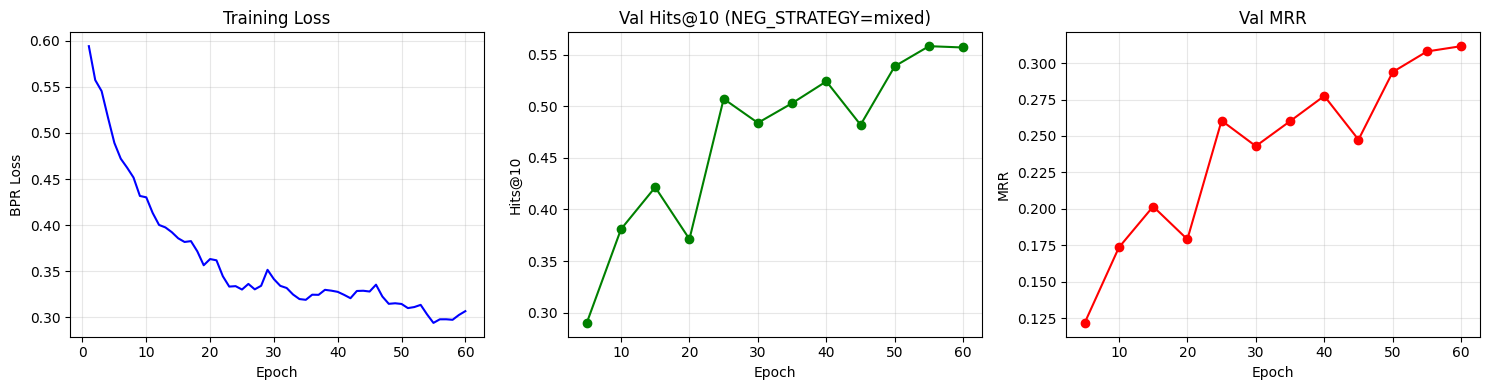

Best val Hits@10: 0.5582 (epoch 55)
Best val MRR:     0.3116 (epoch 60)


In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(range(1, len(train_losses) + 1), train_losses, 'b-')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BPR Loss')
axes[0].set_title('Training Loss'); axes[0].grid(True, alpha=0.3)
axes[1].plot(eval_epochs, val_hits, 'g-o')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Hits@10')
axes[1].set_title(f'Val Hits@10 (NEG_STRATEGY={NEG_STRATEGY})'); axes[1].grid(True, alpha=0.3)
axes[2].plot(eval_epochs, val_mrrs, 'r-o')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('MRR')
axes[2].set_title('Val MRR'); axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./data/graphsage_v2_training.png', dpi=100, bbox_inches='tight')
plt.show()
if val_hits:
    print(f"Best val Hits@10: {max(val_hits):.4f} (epoch {eval_epochs[int(np.argmax(val_hits))]})")
    print(f"Best val MRR:     {max(val_mrrs):.4f} (epoch {eval_epochs[int(np.argmax(val_mrrs))]})")

## Step 13 — Final test evaluation

Two regimes reported:
1. **1K mixed pool** — apples-to-apples vs val and vs the upcoming GAT/HetGAT runs. Same eval composition all the way.
2. **Full pool (~546K)** — the realistic recommender number. This is the headline. Numbers will be substantially lower than the 1K version because the model now has to outrank hundreds of thousands of distractors instead of 999.

In [24]:
test_data = torch.load(PROCESSED_DIR / "test.pt", weights_only=False)

test_1k = evaluate(encoder, decoder, test_data, device)
print("=" * 50)
print(f"GraphSAGE v2 (NEG_STRATEGY={NEG_STRATEGY}) — TEST")
print("=" * 50)
print(f"\n[1K mixed pool, 50/50 hard/random]")
print(f"  Hits@10: {test_1k['hits@10']:.4f}")
print(f"  MRR:     {test_1k['mrr']:.4f}")
print(f"  Authors: {test_1k['num_authors']}")

test_full = evaluate_full_pool(encoder, decoder, test_data, device)
print(f"\n[Full pool — every paper in the pre-test graph]")
print(f"  Hits@10: {test_full['hits@10']:.4f}")
print(f"  MRR:     {test_full['mrr']:.4f}")
print(f"  Authors: {test_full['num_authors']}")

GraphSAGE v2 (NEG_STRATEGY=mixed) — TEST

[1K mixed pool, 50/50 hard/random]
  Hits@10: 0.5669
  MRR:     0.3193
  Authors: 37046

[Full pool — every paper in the pre-test graph]
  Hits@10: 0.0266
  MRR:     0.0132
  Authors: 37046


## Step 14 — Save model

Persist encoder + decoder weights + config + both test numbers (1K mixed + full pool) so we can compare v2 GraphSAGE / GAT / HetGAT side-by-side later. Save path: `models/graphsage_v2_<NEG_STRATEGY>.pt` so multiple ablation runs don't clobber each other.

In [26]:
model_dir = Path("./models")
model_dir.mkdir(exist_ok=True)
save_path = model_dir / f"graphsage_v2_{NEG_STRATEGY}.pt"

torch.save({
    'encoder_state_dict': encoder.state_dict(),
    'decoder_state_dict': decoder.state_dict(),
    'config': {
        'input_dim': INPUT_DIM, 'hidden_dim': HIDDEN_DIM, 'output_dim': OUTPUT_DIM,
        'dropout': DROPOUT, 'lr': LR, 'weight_decay': WEIGHT_DECAY,
        'num_epochs': NUM_EPOCHS, 'batch_size': BATCH_SIZE,
        'neg_strategy': NEG_STRATEGY,
    },
    'val_best': {'hits@10': max(val_hits) if val_hits else 0.0,
                 'mrr': max(val_mrrs) if val_mrrs else 0.0},
    'test_1k_mixed': test_1k,
    'test_full_pool': test_full,
    'train_losses': train_losses,
    'val_hits': val_hits, 'val_mrrs': val_mrrs, 'eval_epochs': eval_epochs,
    'data_version': 'v2',
    'fos_level': metadata.get('fos_level'),
}, save_path)
print(f"Saved {save_path}")

Saved models/graphsage_v2_mixed.pt


## Summary

| Metric | Value |
|---|---|
| NEG_STRATEGY | (see config) |
| Best val Hits@10 (1K mixed) | (see plot) |
| Test Hits@10 (1K mixed) | (cell 13) |
| **Test Hits@10 (full pool)** | **(cell 13 — headline)** |

**Re-run for ablation**: change `NEG_STRATEGY` at the top to `'random'` or `'hard'` and re-run all cells. Three saved checkpoints (`graphsage_v2_random.pt`, `_hard.pt`, `_mixed.pt`) give you the negative-sampling ablation for CLAUDE.md RQ2.

**Next**: `v2_04_gat.ipynb` reusing the same eval functions, swapping SAGEConv for GATConv. Comparing those two answers RQ1 (does heterogeneous attention beat simple graph propagation).